# Full Dataset Gender Extraction

In [2]:
import pandas as pd
import spacy
import re
from tqdm import tqdm
from gender_guesser.detector import Detector

tqdm.pandas(desc="Processing Snippets")

print("Loading spaCy model...")
nlp = spacy.load("en_core_web_sm")

print("Loading Gender Guesser...")
detector = Detector(case_sensitive=False)

print("Loading data...")
df_all = pd.read_csv('../../data/snippets/total_snippets.csv')

metadata_df = pd.read_parquet('../../data/metadata_files/GP_opium_filtered_1850_1930.parquet')
authors_info_df = pd.read_csv('../../data/metadata_files/authors_info.csv')

df_all = df_all.merge(
    metadata_df[['Etext Number', 'Authors', 'LoCC', 'Published Year']],
    left_on='Book_ID',
    right_on='Etext Number',
    how='left'
)

df_all = df_all.merge(
    authors_info_df[['Authors', 'Author Gender']],
    on='Authors',
    how='left'
)
print(f'Total snippets loaded: {len(df_all)}')

Loading spaCy model...
Loading Gender Guesser...
Loading data...
Total snippets loaded: 5370


## NLP Pipeline

Define vocabs for keyword-matching later

In [3]:
MALE_VOCAB = {
    'he', 'him', 'his', 'man', 'boy', 'gentleman',
    'father', 'brother', 'husband', 'uncle',
    'son', 'master', 'sir', 'lord', 'clergyman',
    'mr', 'mister', 'colonel', 'major', 'captain'
}

FEMALE_VOCAB = {
    'she', 'her', 'hers', 'woman', 'girl', 'lady',
    'mother', 'sister', 'wife', 'aunt',
    'daughter', 'mistress', 'widow', 'governess', 
    'nurse', 'mrs', 'miss', 'madam', 'madame'
}

FIRST_PERSON = {
    'i', 'me', 'my', 'mine',
    'we', 'us', 'our', 'ours'
}

SPEECH_VERBS = {
    "say", "said", "reply", "replied",
    "ask", "asked", "remark", "remarked",
    "cry", "cried", "whisper", "whispered",
    "murmur", "murmured"
}

Define utils functions:

In [4]:
# Token role detection
def get_token_role(text):
    """
    Returns:
        ("FirstPerson", None)
        ("ThirdPerson", "Male")
        ("ThirdPerson", "Female")
        (None, None)
    """
    t = text.lower()

    if t in FIRST_PERSON:
        return ("FirstPerson", None)

    if t in MALE_VOCAB:
        return ("ThirdPerson", "Male")

    if t in FEMALE_VOCAB:
        return ("ThirdPerson", "Female")

    return (None, None)


# Context fallback
def get_contextual_scores(doc, kw_idx, window=30):
    scores = { "Male": 0.0, "Female": 0.0 }

    start = max(0, kw_idx - window)
    end = min(len(doc), kw_idx + window)

    for i in range(start, end):
        token = doc[i]
        role, gender = get_token_role(token.text)

        if role == "ThirdPerson":
            distance = abs(i - kw_idx)
            weight = max(0.1, 1 - (distance / window))
            scores[gender] += weight

    return scores

# Dialogue detection (for first-person resolution)
def keyword_in_dialogue(text, keyword):
    pattern = (
        r'["“][^"”]*'
        + re.escape(keyword.lower())
        + r'[^"”]*["”]'
    )

    return bool(re.search(pattern, text.lower()))

# Speaker resolution (1st person)
def resolve_dialogue_speaker(doc, kw_token):
    window_start = max(0, kw_token.i - 50)
    window_end = min(len(doc), kw_token.i + 50)

    nearby = doc[window_start:window_end]
    for token in nearby:
        if token.lemma_.lower() in SPEECH_VERBS:
            for child in token.children:
                # pronoun subjects
                role, gender = get_token_role(child.text)

                if role == "ThirdPerson":
                    return gender, child.text

                # named PERSON entities
                for ent in doc.ents:
                    if (ent.label_ == "PERSON" and ent.start <= child.i < ent.end):
                        first_name = ent.text.split()[0]
                        guess = detector.get_gender(first_name)
                        if "female" in guess:
                            return "Female", ent.text

                        elif "male" in guess:
                            return "Male", ent.text

    return "Unknown", "Anonymous"

# Character name resolution (1st person)
def resolve_character_name(doc, keyword_idx, target_gender):
    candidates = []
    for ent in doc.ents:
        if ent.label_ != "PERSON":
            continue
        first_name = ent.text.split()[0]
        guess = detector.get_gender(first_name)

        is_match = (
            (target_gender == "Female" and "female" in guess)
            or
            (target_gender == "Male" and "male" in guess)
            or
            (guess == "unknown")
        )

        if is_match:
            dist = abs(ent.start - keyword_idx)
            candidates.append((ent.text, dist))

    if candidates:
        return sorted(candidates, key=lambda x: x[1])[0][0]

    return "Anonymous"


# First-person narration
def resolve_first_person_narrator(row, scores):
    genres = row.get('Genres', [])
    author_gender = str(row.get('Author Gender', '')).lower()
    is_fiction = 'Fiction' in genres

    # non-fiction:
    # assume narrator ~= author
    if not is_fiction:
        if author_gender in ['male', 'female']:
            return author_gender.title()

        return "Unknown"

    # fiction:
    # weak contextual fallback
    if scores["Male"] > scores["Female"] * 1.5:
        return "Male"

    if scores["Female"] > scores["Male"] * 1.5:
        return "Female"

    if author_gender in ['male', 'female']:
        return author_gender.title()

    return "Unknown"

Main pipeline

In [5]:
def extract_opium_identity(row):
    text = str(row['Snippet'])
    keyword = str(row['Keyword']).lower()
    doc = nlp(text)

    # 1. Locate keyword token & FILTER PROPER NOUNS (e.g., Dr. Anodyne)
    kw_token = next((t for t in doc if t.lemma_.lower() == keyword), None)
    
    if not kw_token or kw_token.pos_ == "PROPN":
        return "Unknown (Proper Noun)", "Anonymous"

    final_gender = "Unknown"
    character_name = "Anonymous"

    # -----------------------------------------------------
    # STEP A: DEPENDENCY PARSING
    # -----------------------------------------------------
    head = kw_token
    while head.head != head and head.pos_ != "VERB":
        head = head.head

    detected_first_person = False
    
    # Look for Subjects and Objects (dobj, pobj, dative)
    target_deps = {"nsubj", "nsubjpass", "poss", "dobj", "pobj", "dative", "attr"}

    for child in head.children:
        if child.dep_ in target_deps:
            role, gender = get_token_role(child.text)
            
            if role == "FirstPerson":
                detected_first_person = True
                break
            elif role == "ThirdPerson":
                final_gender = gender
                # Try to see if this pronoun refers to a nearby name
                character_name = resolve_character_name(doc, child.i, gender)
                break
            
            # NEW: If it's a NAME (not in vocab), check gender immediately
            elif child.ent_type_ == "PERSON":
                first_name = child.text.split()[0]
                guess = detector.get_gender(first_name)
                if "female" in guess:
                    final_gender = "Female"
                    character_name = child.text
                    break
                elif "male" in guess:
                    final_gender = "Male"
                    character_name = child.text
                    break

    # -----------------------------------------------------
    # STEP B: FIRST-PERSON RESOLUTION (Narrator vs Dialogue)
    # -----------------------------------------------------
    if detected_first_person:
        if keyword_in_dialogue(text, keyword):
            final_gender, character_name = resolve_dialogue_speaker(doc, kw_token)
        else:
            scores = get_contextual_scores(doc, kw_token.i)
            final_gender = resolve_first_person_narrator(row, scores)

    # -----------------------------------------------------
    # STEP C: CONTEXTUAL FALLBACK
    # -----------------------------------------------------
    if final_gender == "Unknown":
        scores = get_contextual_scores(doc, kw_token.i)
        m, f = scores["Male"], scores["Female"]
        if m > f * 1.5: final_gender = "Male"
        elif f > m * 1.5: final_gender = "Female"

    # -----------------------------------------------------
    # STEP D: FINAL NAME CLEANUP
    # -----------------------------------------------------
    if final_gender in ["Male", "Female"] and character_name == "Anonymous":
        character_name = resolve_character_name(doc, kw_token.i, final_gender)

    return final_gender, character_name

## Step 2: Execute and Export

In [ ]:
df_all[['Assigned_Gender', 'Character_Name']] = df_all.progress_apply(extract_opium_identity, axis=1, result_type='expand')

print("\nExecution Complete!")
print("\n=== Gender Distribution ===")
print(df_all['Assigned_Gender'].value_counts())
print("\n=== Keyword x Gender ===")
ct = pd.crosstab(df_all['Keyword'], df_all['Assigned_Gender'])
print(ct.to_string())

In [ ]:
# Export CSV
output_csv = '../../data/snippets/total_snippets_with_gender.csv'
df_all.to_csv(output_csv, index=False, encoding='utf-8-sig')
print(f"\nSaved to {output_csv}")

# Export parquet
output_parquet = '../../data/snippets/total_snippets_with_gender.parquet'
df_all.to_parquet(output_parquet, index=False)
print(f"Saved to {output_parquet}")


Saved to ../../data/snippets/total_snippets_with_gender.csv
Saved to ../../data/snippets/total_snippets_with_gender.parquet


## Diagnostic Plots

In [7]:
output_csv = '../../data/snippets/total_snippets_with_gender.csv'
df_all = pd.read_csv(output_csv)
df_all

,Unnamed: 0,Book_ID,Keyword,Snippet,Etext Number,Authors,LoCC,Published Year,Author Gender,Assigned_Gender,Character_Name
0,0,15,opium,they would rather not see whales than otherwis...,15,"Melville, Herman",PS,1851,male,Male,Whales
1,1,15,paregoric,questionable; for it is not customary for such...,15,"Melville, Herman",PS,1851,male,Male,Stubb
2,2,15,laudanum,previous when the Pequod spoke the Town-Ho. Ac...,15,"Melville, Herman",PS,1851,male,Male,Jeroboam
3,3,44,opium,and scared you! Nothing to cry about. I’m the ...,44,"Cather, Willa",PS,1915,female,Female,Kronborg
4,4,95,narcotic,"that?” he asked. “Why this,” I answered. “That...",95,"Hope, Anthony",PR,1894,male,Male,Rupert Hentzau
...,...,...,...,...,...,...,...,...,...,...,...
5365,6652,74690,narcotic,men called progress brought nothing but aches ...,74690,"Hankins, Arthur Preston",PS,1925,NaN,Male,Fate
5366,6654,75372,anodyne,"word was law, moved softly up and down stairs ...",75372,"Stuart, Henry Longan",PS,1926,NaN,Female,Anonymous
5367,6655,75518,opium,"then, but not until formally invited, fills hi...",75518,"Dehan, Richard",PR,1922,female,Male,Fadl Anga
5368,6656,75518,opium,"Shaykh, sending out a volume of cigarette-smok...",75518,"Dehan, Richard",PR,1922,female,Male,Shaykh


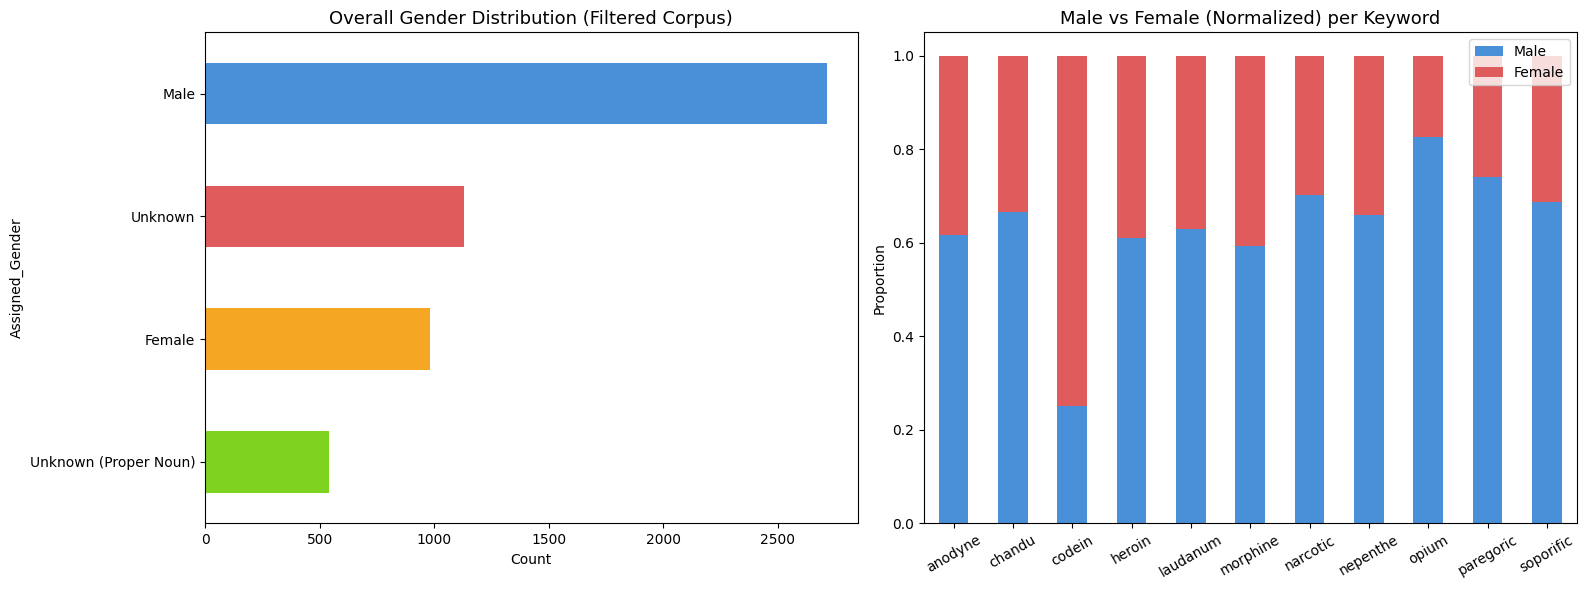

Plots saved.


In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Overall gender distribution
gender_counts = df_all['Assigned_Gender'].value_counts()
colors = ['#4A90D9', '#E05B5B', '#F5A623', '#7ED321', '#9B59B6', '#1ABC9C', '#F39C12']
gender_counts.plot(kind='barh', ax=axes[0], color=colors[:len(gender_counts)])
axes[0].set_title('Overall Gender Distribution (Filtered Corpus)', fontsize=13)
axes[0].set_xlabel('Count')
axes[0].invert_yaxis()

# Plot 2: Male vs Female per keyword (stacked bar, normalized)
mf = df_all[df_all['Assigned_Gender'].isin(['Male', 'Female'])]
pivot = mf.groupby(['Keyword', 'Assigned_Gender']).size().unstack(fill_value=0)
pivot = pivot[['Male', 'Female']] # Enforce column order so colors match legend
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)
pivot_norm.plot(kind='bar', stacked=True, ax=axes[1], color=['#4A90D9', '#E05B5B'])
axes[1].set_title('Male vs Female (Normalized) per Keyword', fontsize=13)
axes[1].set_ylabel('Proportion')
axes[1].set_xlabel('')
axes[1].legend(['Male', 'Female'])
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../../data/snippets/gender_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plots saved.")


In [ ]:
pd.set_option('display.max_colwidth', None)

In [10]:
assessment_path = '../../data/snippets/random_snippet_gender_assessment.csv'
df_all[['Snippet', 'Keyword', 'Assigned_Gender', "Character_Name"]].sample(50, random_state = 23).to_csv(assessment_path)

Using a random sample of 50 snippets and their assigned gender we manually assessed the accuracy of the gender retrieval. (See manual annotations [here](https://docs.google.com/spreadsheets/d/1k1y3ogOTEeAuqrMxNOMVdQ2XvXiipUXpTLqR3vD8i4M/edit?usp=sharing)).

Our method reached an overall accuracy of **73.5%**. The confusion matrix is displayed below:

| Predicted \\ Ground Truth | **Male** | **Female** | **Unknown** | **Precision** |
|---|---:|---:|---:|---:|
| **Male** | 25 | 4 | 4 | 75.8% |
| **Female** | 1 | 7 | 0 | 87.5% |
| **Unknown** | 4 | 0 | 4 | 50.0% |
| **Recall** | 83.3% | 63.6% | 50.0% |  |

We consider this accuracy sufficient to cary-on our analysis, but the high precision and recall variations will have to be taken into consideration.

Plot saved as gender_trend_over_time.png


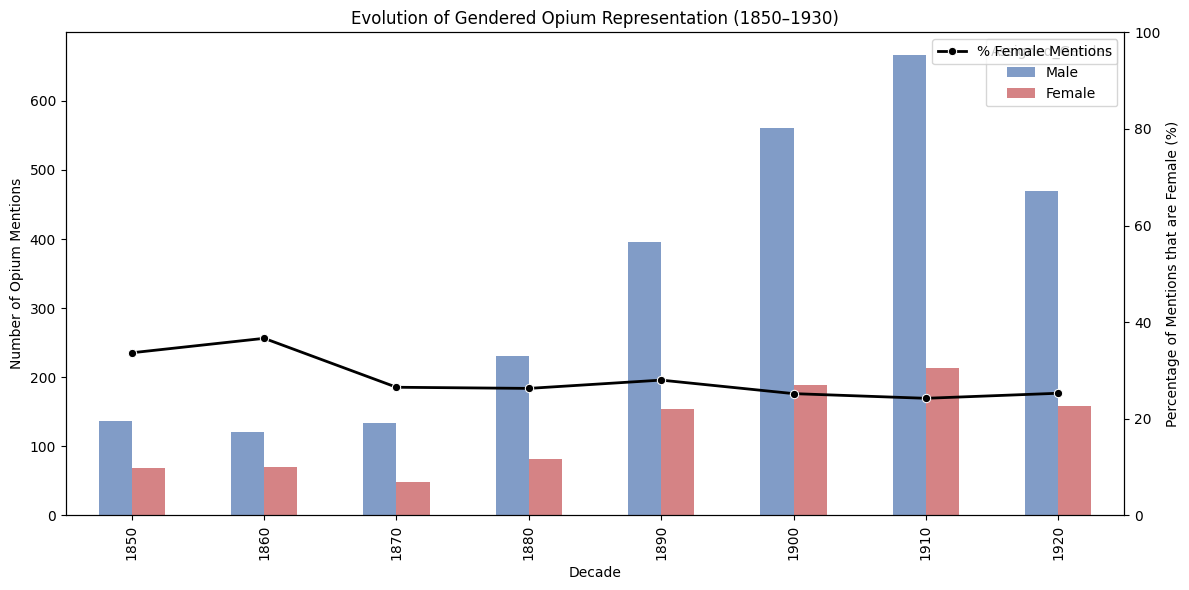

In [15]:
import seaborn as sns

def plot_gender_trends(df):
    # 1. Clean the year and create a Decade column
    # Assuming 'Year' is your column name from the Chronoberg data
    df = df[df['Published Year'].notnull()].copy()
    df['Decade'] = (df['Published Year'] // 10) * 10
    
    # 2. Filter to our primary comparison groups (excluding Unknowns for the trend)
    trend_df = df[df['Assigned_Gender'].isin(['Male', 'Female'])]
    
    # 3. Create a pivot table of counts per decade
    dist = trend_df.groupby(['Decade', 'Assigned_Gender']).size().unstack(fill_value=0)
    
    # 4. Calculate Percentage of Female Mentions (The "Visibility" Metric)
    dist['Total'] = dist['Male'] + dist['Female']
    dist['% Female'] = (dist['Female'] / dist['Total']) * 100

    # 5. Plotting
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Bar chart for raw counts
    dist[['Male', 'Female']].plot(kind='bar', ax=ax1, color=['#4C72B0', '#C44E52'], alpha=0.7)
    ax1.set_ylabel('Number of Opium Mentions')
    ax1.set_xlabel('Decade')
    ax1.set_title('Evolution of Gendered Opium Representation (1850–1930)')

    # Line chart for the percentage (The "Rupture" line)
    ax2 = ax1.twinx()
    sns.lineplot(data=dist, x=range(len(dist)), y='% Female', ax=ax2, color='black', marker='o', linewidth=2, label='% Female Mentions')
    ax2.set_ylabel('Percentage of Mentions that are Female (%)')
    ax2.set_ylim(0, 100)
    
    plt.tight_layout()
    plt.savefig('../../data/snippets/gender_trend_over_time.png')
    print("Plot saved as gender_trend_over_time.png")

# Run the plot
plot_gender_trends(df_all)

The data reveals a consistent 3:1 male-to-female ratio, reflecting the historical dominance of male archetypes in the literary market. The noticeable dip in female visibility between 1860 and 1880 aligns with the 1868 Pharmacy Act, suggesting that increased regulation may have pushed female consumption further into the "invisible" domestic sphere. While the raw volume of mentions exploded during the 1890–1910 "Golden Age" of urban sensationalism, the percentage of female mentions remained stable (~25%). 

Plot saved as opium_keyword_trend_over_time.png


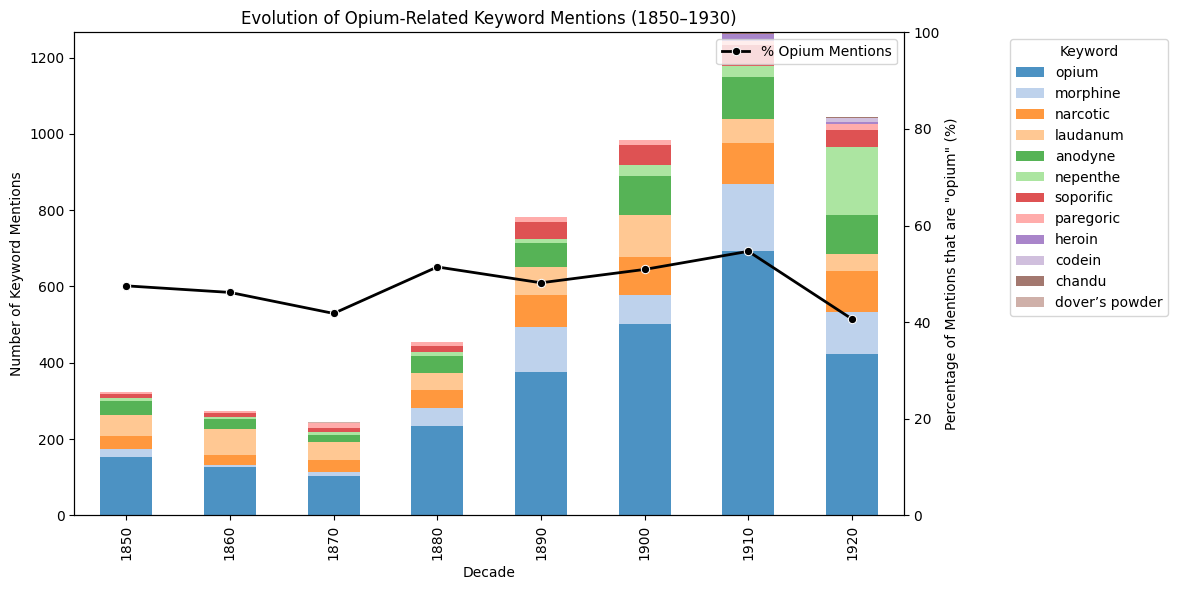

In [16]:
# Opium keywords trends

def plot_opium_keyword_trends(df, top_n=None):
    # 1. Clean the year and create a Decade column
    df = df[df['Published Year'].notnull()].copy()
    df['Decade'] = (df['Published Year'].astype(int) // 10) * 10
    df['Keyword'] = df['Keyword'].astype(str).str.lower().str.strip()

    # 2. Order keywords by frequency, with an optional top_n for presentation plots
    keyword_order = df['Keyword'].value_counts().index.tolist()
    if top_n is not None:
        keyword_order = keyword_order[:top_n]
    trend_df = df[df['Keyword'].isin(keyword_order)]

    # 3. Create a pivot table of keyword counts per decade
    dist = trend_df.groupby(['Decade', 'Keyword']).size().unstack(fill_value=0)
    dist = dist.reindex(columns=keyword_order, fill_value=0).sort_index()

    # 4. Calculate the percentage of mentions using the literal "opium" keyword
    dist['Total'] = dist[keyword_order].sum(axis=1)
    if 'opium' in dist.columns:
        dist['% Opium'] = (dist['opium'] / dist['Total']) * 100
    else:
        dist['% Opium'] = 0

    # 5. Plotting
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Bar chart for raw keyword counts
    palette = sns.color_palette('tab20', n_colors=len(keyword_order))
    dist[keyword_order].plot(kind='bar', stacked=True, ax=ax1, color=palette, alpha=0.8)
    ax1.set_ylabel('Number of Keyword Mentions')
    ax1.set_xlabel('Decade')
    ax1.set_title('Evolution of Opium-Related Keyword Mentions (1850–1930)')
    ax1.legend(title='Keyword', bbox_to_anchor=(1.12, 1), loc='upper left')

    # Line chart for the percentage of literal opium mentions
    ax2 = ax1.twinx()
    sns.lineplot(data=dist, x=range(len(dist)), y='% Opium', ax=ax2, color='black', marker='o', linewidth=2, label='% Opium Mentions')
    ax2.set_ylabel('Percentage of Mentions that are "opium" (%)')
    ax2.set_ylim(0, 100)

    plt.tight_layout()
    plt.savefig('../../data/snippets/opium_keyword_trend_over_time.png', dpi=150, bbox_inches='tight')
    print("Plot saved as opium_keyword_trend_over_time.png")

# Run the plot
plot_opium_keyword_trends(df_all)